In [1]:
# =========================
# 03 MONTE CARLO
# =========================

import xarray as xr
import numpy as np

# Load saved data
ds_melt = xr.open_dataset(r"P:\snowmelt_stochastic_model\data\processed\melt_models.nc")
sigma = xr.open_dataarray(r"P:\snowmelt_stochastic_model\data\processed\sigma.nc")

# Extract deterministic melt
melt_det = ds_melt["melt_det"]

time = melt_det["time"]
n = len(time)

print("Data loaded for Monte Carlo")

Data loaded for Monte Carlo


In [2]:
# =========================
# MONTE CARLO ENSEMBLE
# =========================

n_sim = 50
phi = 0.7

ensemble = []

for i in range(n_sim):
    
    eta = np.random.normal(0, 1, n)
    epsilon = np.zeros(n)
    
    for t in range(1, n):
        epsilon[t] = phi * epsilon[t-1] + eta[t]
    
    melt_sim = melt_det + sigma * epsilon
    melt_sim = melt_sim.clip(min=0, max=80)
    
    ensemble.append(melt_sim.values)

ensemble = np.array(ensemble)

print("Monte Carlo complete:", ensemble.shape)

Monte Carlo complete: (50, 1826)


In [3]:
# =========================
# UNCERTAINTY BANDS
# =========================

p10 = np.percentile(ensemble, 10, axis=0)
p90 = np.percentile(ensemble, 90, axis=0)
mean_mc = np.mean(ensemble, axis=0)

print("Uncertainty bands computed")

Uncertainty bands computed


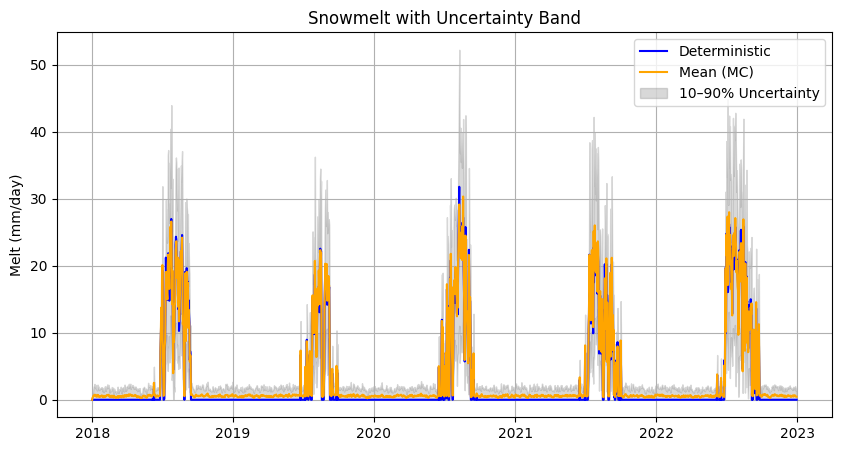

In [4]:
# =========================
# FINAL UNCERTAINTY PLOT
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(time, melt_det, label="Deterministic", color='blue')
plt.plot(time, mean_mc, label="Mean (MC)", color='orange')

plt.fill_between(
    time.values,
    p10,
    p90,
    color='gray',
    alpha=0.3,
    label="10–90% Uncertainty"
)

plt.title("Snowmelt with Uncertainty Band")
plt.ylabel("Melt (mm/day)")
plt.legend()
plt.grid()

plt.show()

In [5]:
plt.savefig(r"P:\snowmelt_stochastic_model\outputs\figures\uncertainty_plot.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [6]:
# =========================
# SAVE MONTE CARLO ENSEMBLE
# =========================

import numpy as np

np.save(
    r"P:\snowmelt_stochastic_model\data\processed\monte_carlo_ensemble.npy",
    ensemble
)

print("Monte Carlo ensemble saved successfully")

Monte Carlo ensemble saved successfully
